In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.cluster import DBSCAN, MeanShift
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [39]:
df= pd.read_csv('../data collections/cancer.csv')
df

,Id,Diagnosis,Radius (mean),Texture (mean),Perimeter (mean),Area (mean),Smoothness (mean),Compactness (mean),Concavity (mean),Concave points (mean),Symmetry (mean),Fractal dimension (mean),Radius (se),Texture (se),Perimeter (se),Area (se),Smoothness (se),Compactness (se),Concavity (se),Concave points (se),Symmetry (se),Fractal dimension (se),Radius (worst),Texture (worst),Perimeter (worst),Area (worst),Smoothness (worst),Compactness (worst),Concavity (worst),Concave points (worst),Symmetry (worst),Fractal dimension (worst)
0,8510426,B,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,0.2699,0.7886,2.058,23.560,0.008462,0.014600,0.02387,0.013150,0.01980,0.002300,15.110,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259
1,8510653,B,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,0.1852,0.7477,1.383,14.670,0.004097,0.018980,0.01698,0.006490,0.01678,0.002425,14.500,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183
2,8510824,B,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,0.2773,0.9768,1.909,15.700,0.009606,0.014320,0.01985,0.014210,0.02027,0.002968,10.230,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773
3,854941,B,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,0.1839,2.3420,1.170,14.160,0.004352,0.004899,0.01343,0.011640,0.02671,0.001777,13.300,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169
4,85713702,B,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,0.1563,0.9567,1.094,8.205,0.008968,0.016460,0.01588,0.005917,0.02574,0.002582,8.964,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926125,M,20.920,25.09,143.00,1347.0,0.10990,0.22360,0.31740,0.147400,0.2149,0.06879,0.9622,1.0260,8.758,118.800,0.006399,0.043100,0.07845,0.026240,0.02057,0.006213,24.290,29.41,179.10,1819.0,0.14070,0.41860,0.65990,0.25420,0.2929,0.09873
565,926424,M,21.560,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.138900,0.1726,0.05623,1.1760,1.2560,7.673,158.700,0.010300,0.028910,0.05198,0.024540,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.41070,0.22160,0.2060,0.07115
566,926682,M,20.130,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.097910,0.1752,0.05533,0.7655,2.4630,5.203,99.040,0.005769,0.024230,0.03950,0.016780,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.32150,0.16280,0.2572,0.06637
567,926954,M,16.600,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.053020,0.1590,0.05648,0.4564,1.0750,3.425,48.550,0.005903,0.037310,0.04730,0.015570,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.34030,0.14180,0.2218,0.07820


In [40]:
print(df.nunique())
print(df.info())


Id                           569
Diagnosis                      2
Radius (mean)                456
Texture (mean)               479
Perimeter (mean)             522
Area (mean)                  539
Smoothness (mean)            474
Compactness (mean)           537
Concavity (mean)             537
Concave points (mean)        542
Symmetry (mean)              432
Fractal dimension (mean)     499
Radius (se)                  540
Texture (se)                 519
Perimeter (se)               533
Area (se)                    528
Smoothness (se)              547
Compactness (se)             541
Concavity (se)               533
Concave points (se)          507
Symmetry (se)                498
Fractal dimension (se)       545
Radius (worst)               457
Texture (worst)              511
Perimeter (worst)            514
Area (worst)                 544
Smoothness (worst)           411
Compactness (worst)          529
Concavity (worst)            539
Concave points (worst)       492
Symmetry (

In [41]:
if df["Diagnosis"].dtype == "object":
    df["Diagnosis"] = df["Diagnosis"].map({
        "M": 1,
        "B": 0
    })

In [42]:
scaler=StandardScaler()

In [54]:
X= df.drop(['Id', 'Diagnosis'], axis=1)
y= df['Diagnosis']

In [44]:
X_train, X_test, y_train, y_test= train_test_split(X, y, stratify=y, test_size=0.2)

In [45]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_train)

In [46]:
dbscan = DBSCAN(
    eps=2.0,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_train_scaled)



In [47]:

import numpy as np

print("DBSCAN labels:", np.unique(dbscan_labels))
print("Antal kluster:", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print("Antal brus/outliers:", list(dbscan_labels).count(-1))

DBSCAN labels: [-1  0  1  2  3]
Antal kluster: 4
Antal brus/outliers: 310


In [48]:
from sklearn.cluster import MeanShift, estimate_bandwidth

bandwidth = estimate_bandwidth(
    X_train_scaled,
    quantile=0.2
)

meanshift = MeanShift(
    bandwidth=bandwidth,
    cluster_all=False
)

meanshift_labels = meanshift.fit_predict(X_train_scaled)

print("Bandwidth:", bandwidth)
print("Mean Shift labels:", np.unique(meanshift_labels))
print("Antal kluster:", len(np.unique(meanshift_labels)))

Bandwidth: 4.981540752108467
Mean Shift labels: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
Antal kluster: 22


In [49]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

print("Explained variance:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance: [0.44186448 0.19144387]
Total explained variance: 0.6333083488814151


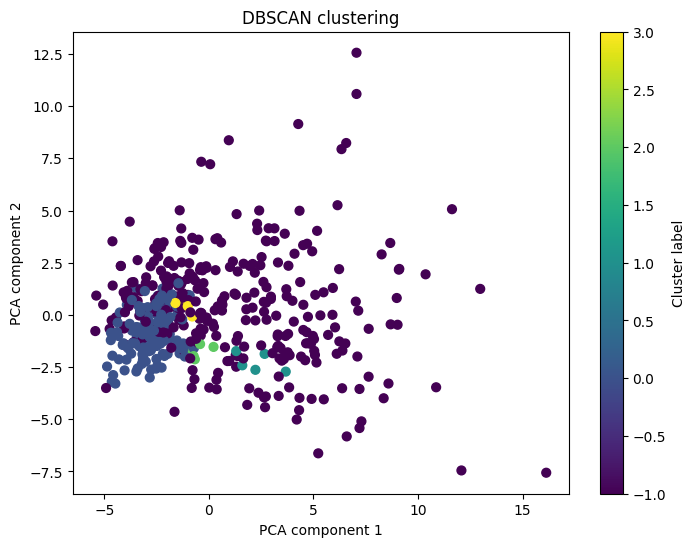

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    cmap="viridis",
    s=40
)

plt.title("DBSCAN clustering")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.colorbar(label="Cluster label")
plt.show()

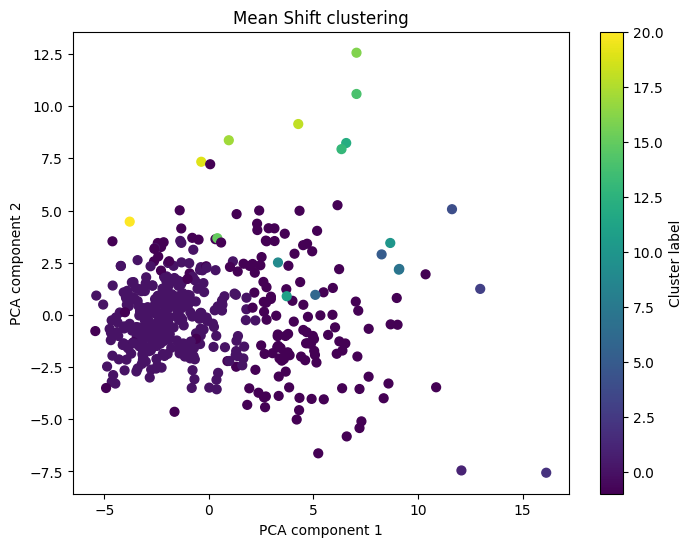

In [51]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=meanshift_labels,
    cmap="viridis",
    s=40
)

plt.title("Mean Shift clustering")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.colorbar(label="Cluster label")
plt.show()

ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not 0      B
1      B
2      B
3      B
4      B
      ..
564    M
565    M
566    M
567    M
568    M
Name: Diagnosis, Length: 569, dtype: str

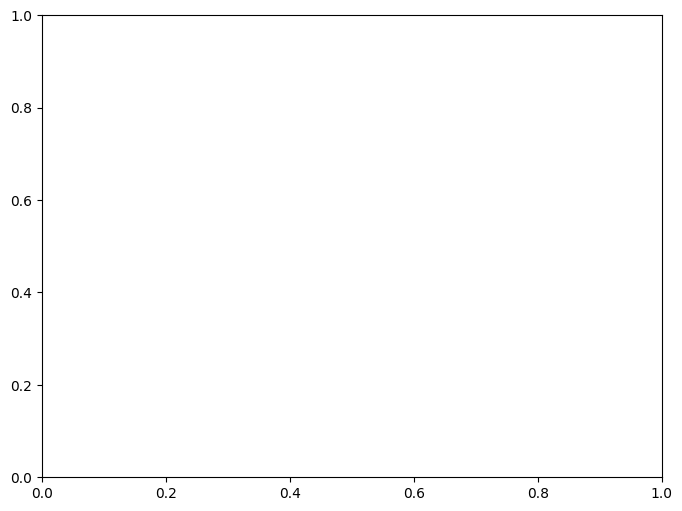

In [56]:


plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis",
    s=40
)

plt.title("Riktiga labels: Malignant vs Benign")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.colorbar(label="Diagnosis")
plt.show()